# 08 — Unified Panel Sweep (3-Stage)

Three-stage pipeline over **3 candidate panels × 3 reductors × M classifiers**.

| Stage | Purpose | Output |
|-------|---------|--------|
| **1** | For each N: nested 5-fold CV across 3 panels × 3 reductors (RF, LR, EN). Find best (panel, reductor) per N. | `stage1_best.csv` |
| **2** | For each N: run M classifiers using the Stage-1 winner config, ranker re-fit inside each fold. | `stage2_best.csv` |
| **3** | For each N: 80/20 split, fit reductor on 80%, commit final SNP list, test best classifier from Stage 2. | `panels/panel_N*.csv` |

**Leakage notes:**
- Ranker is re-fit inside every CV fold → no feature-selection leakage.
- FST/stat candidate-set selection used all 504 samples (filter-method, not model-fit; disclosed but not fixable without per-fold genome-wide recomputation).
- Stage 1 config selection used all 504 samples (standard model-selection bias, unavoidable at n=504).

**Run order:** `05a → 05c → this notebook`

In [1]:
import sys, os, time, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

_r = next(p for p in [Path.cwd(), *Path.cwd().parents]
          if (p / 'scripts' / 'config.py').exists())
sys.path.insert(0, str(_r / 'scripts'))
from notebook_init import setup
cfg, PATHS, POPULATIONS, HARD_FILTERS, SITUATIONAL_FILTERS, ML = setup()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score,
                             matthews_corrcoef, roc_auc_score)
from xgboost import XGBClassifier
print('Imports OK')

Project root : /home/ibmelab/Projects/AISNP_Research
genomes_data : /mnt/data/aisnp_data/1000genomes/
output root  : output


Imports OK


In [2]:
OUTPUT_DIR = PATHS.outputs_dir('self_evaluation/08_unified_panel_sweep')
PANELS_DIR = OUTPUT_DIR / 'panels'
os.makedirs(str(OUTPUT_DIR), exist_ok=True)
os.makedirs(str(PANELS_DIR), exist_ok=True)
print(f'Output: {OUTPUT_DIR}')

Output: /mnt/data/aisnp_data/1000genomes/outputs/self_evaluation/08_unified_panel_sweep


## Load Candidate Sets

| Panel | Source | Size |
|-------|--------|------|
| FST | `04b_fst_and_pca` ML_DATA CSV | 2508 SNPs |
| V2 stat | numpy cache + union top-500 SNPs from `05a` | 1005 SNPs |
| V2 FST+stat | ML_DATA CSV filtered to `05c` consensus SNPs | 1003 SNPs |

In [3]:
# ── FST candidate set ─────────────────────────────────────────────────────────
fst_df = pd.read_csv(str(PATHS.ML_DATA))
snp_cols_fst_raw = [c for c in fst_df.columns if c not in ['sample', 'pop']]
snp_cols_fst = [
    c.replace('[', '_').replace(']', '_').replace('<', '_')
    for c in snp_cols_fst_raw
]
X_fst = fst_df[snp_cols_fst_raw].values.astype(np.float32)
y_fst_str = fst_df['pop'].values
print(f'FST:  {X_fst.shape}  {dict(zip(*np.unique(y_fst_str, return_counts=True)))}')

FST:  (504, 2508)  {'CN': np.int64(208), 'JPT': np.int64(104), 'SEA': np.int64(192)}


In [4]:
# ── stat candidate set (union top-500 = 1005 SNPs) ────────────────────────
print('Loading genotype matrix...')
t0 = time.time()
data = np.load(str(PATHS.GENOTYPE_MATRIX))
G_raw = data['G']
sample_names_np = list(data['samples'].astype(str))
with open(str(PATHS.GENOTYPE_MATRIX_COLS)) as fh:
    all_snp_ids = [ln.strip() for ln in fh]
snp_index = {s: i for i, s in enumerate(all_snp_ids)}
print(f'Loaded in {time.time()-t0:.1f}s  shape: {G_raw.shape}')

# SNP IDs from 05a feature importance file (1005 SNPs — union top-500)
prefix_05a = str(PATHS.outputs_dir('statistical/05a_stat_training'))
imp_path_05a = prefix_05a + '_feature_importance.csv'
if not os.path.exists(imp_path_05a):
    raise FileNotFoundError('Run 05a_stat_training first: ' + imp_path_05a)
imp_05a = pd.read_csv(imp_path_05a)
vstat_snp_ids_raw = imp_05a['snp_id'].tolist()

vstat_idx = [snp_index[s] for s in vstat_snp_ids_raw if s in snp_index]
X_vstat = G_raw[:, vstat_idx].astype(np.float32)
snp_cols_vstat = [
    all_snp_ids[i].replace('[','_').replace(']','_').replace('<','_')
    for i in vstat_idx
]

# Align y with numpy cache sample order
samples_meta = pd.read_csv(str(PATHS.SAMPLES_CSV), header=None,
                            names=['sample', 'pop', 'super_pop'])
pop_lookup = dict(zip(samples_meta['sample'], samples_meta['pop']))
y_vstat_str = np.array([pop_lookup.get(s, 'UNK') for s in sample_names_np])
print(f'V2 stat: {X_vstat.shape}  {dict(zip(*np.unique(y_vstat_str, return_counts=True)))}')

Loading genotype matrix...


Loaded in 0.7s  shape: (504, 614759)
V2 stat: (504, 1005)  {np.str_('CN'): np.int64(208), np.str_('JPT'): np.int64(104), np.str_('SEA'): np.int64(192)}


In [5]:
# ── FST+stat candidate set (1003 consensus SNPs) ──────────────────────────
# consensus_snp_stats.csv holds ALL 2508 FST SNP statistics — NOT just the 1003
# that pass the consensus filter (chi² FDR + top-50% MI + top-50% KL).
# Instead, load rf_feature_importances.csv from 05c: it was built on X_consensus
# (already filtered to the 1003 SNPs), so its 'feature' column is exactly the
# right list. Reverse-map sanitized names back to raw FST column names.
prefix_05c = str(PATHS.outputs_dir('statistical/05c_fst_stat_training'))
rf_imp_path = prefix_05c + '/rf_feature_importances.csv'
if not os.path.exists(rf_imp_path):
    raise FileNotFoundError('Run 05c_fst_stat_training first: ' + rf_imp_path)

rf_imp_05c = pd.read_csv(rf_imp_path)

# sanitized_name -> raw FST column name
sanitized_to_raw = {
    c.replace('[','_').replace(']','_').replace('<','_'): c
    for c in snp_cols_fst_raw
}
consensus_snps_raw = [sanitized_to_raw[f] for f in rf_imp_05c['feature']
                      if f in sanitized_to_raw]
consensus_snps     = [f for f in rf_imp_05c['feature'] if f in sanitized_to_raw]

X_vfststat = fst_df[consensus_snps_raw].values.astype(np.float32)
y_vfststat_str = fst_df['pop'].values
print(f'V2 FST+stat: {X_vfststat.shape}  {dict(zip(*np.unique(y_vfststat_str, return_counts=True)))}')
print(f'Consensus SNPs loaded: {len(consensus_snps_raw)}')

V2 FST+stat: (504, 1003)  {'CN': np.int64(208), 'JPT': np.int64(104), 'SEA': np.int64(192)}
Consensus SNPs loaded: 1003


## Configuration

In [6]:
RANDOM_STATE = 42
N_CV = 5
PANEL_SIZES = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 90, 100]

# Encode all y to integers (0=CN, 1=JPT, 2=SEA) — consistent across all classifiers
le = LabelEncoder()
le.fit(np.unique(np.concatenate([y_fst_str, y_vstat_str, y_vfststat_str])))
y_fst      = le.transform(y_fst_str)
y_vstat    = le.transform(y_vstat_str)
y_vfststat = le.transform(y_vfststat_str)
print(f'Classes: {le.classes_}')

# Candidate panels: name -> (X, y_int, snp_id_list)
PANELS = {
    'FST':       (X_fst,        y_fst,      snp_cols_fst),
    'stat':    (X_vstat,      y_vstat,    snp_cols_vstat),
    'fst_stat': (X_vfststat,   y_vfststat, consensus_snps),
}
REDUCTORS = ['RF', 'LR', 'EN']

# Stage 2 classifiers: name -> (clf_template, needs_scale)
# All receive integer-encoded y. probability=True on SVMs for ROC-AUC (slow).
CLASSIFIERS = {
    'RF':      (RandomForestClassifier(n_estimators=100, max_depth=10,
                    random_state=RANDOM_STATE, n_jobs=-1),              False),
    'XGB':     (XGBClassifier(n_estimators=200, max_depth=6,
                    learning_rate=0.1, subsample=0.8,
                    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0), False),
    'LR':      (LogisticRegression(max_iter=1000,
                    random_state=RANDOM_STATE),                         True),
    'SVM_RBF': (SVC(kernel='rbf', probability=True,
                    random_state=RANDOM_STATE),                         True),
    'SVM_Lin': (SVC(kernel='linear', probability=True,
                    random_state=RANDOM_STATE),                         True),
    'GBM':     (GradientBoostingClassifier(n_estimators=100, max_depth=5,
                    random_state=RANDOM_STATE),                         False),
}

skf = StratifiedKFold(n_splits=N_CV, shuffle=True, random_state=RANDOM_STATE)
print(f'Panels:      {list(PANELS)}')
print(f'Reductors:   {REDUCTORS}')
print(f'Classifiers: {list(CLASSIFIERS)}')
print(f'Panel sizes: {PANEL_SIZES}')

Classes: ['CN' 'JPT' 'SEA']
Panels:      ['FST', 'stat', 'fst_stat']
Reductors:   ['RF', 'LR', 'EN']
Classifiers: ['RF', 'XGB', 'LR', 'SVM_RBF', 'SVM_Lin', 'GBM']
Panel sizes: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 90, 100]


## Helper: fit_reductor

Fits a ranker on `X_tr` (training fold only) and returns
an importance array and the fitted scaler.
Called fresh inside every CV fold — no leakage at the ranking step.

In [7]:
def fit_reductor(rname, X_tr, y_tr):
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X_tr)

    if rname == 'RF':
        red = RandomForestClassifier(n_estimators=200,
                                     random_state=RANDOM_STATE, n_jobs=-1)
        red.fit(X_tr, y_tr)
        return red.feature_importances_, scaler

    if rname == 'LR':
        red = LogisticRegression(max_iter=2000, solver='saga', penalty='l2',
                                 random_state=RANDOM_STATE)
        red.fit(X_sc, y_tr)
        return np.abs(red.coef_).mean(axis=0), scaler

    if rname == 'EN':
        red = LogisticRegression(max_iter=2000, solver='saga',
                                 penalty='elasticnet', l1_ratio=0.5,
                                 random_state=RANDOM_STATE)
        red.fit(X_sc, y_tr)
        return np.abs(red.coef_).mean(axis=0), scaler

    raise ValueError(f'Unknown reductor: {rname}')

print('fit_reductor defined.')

fit_reductor defined.


## Stage 1: Nested CV — Find Best (Panel, Reductor) per N

For each `(panel, reductor)` combination:
1. Run 5-fold CV. In each fold, fit the reductor on the training fold only.
2. For efficiency, the fold ranking is computed **once per (panel, reductor, fold)**
   and reused across all N values (top-N slicing).
3. Evaluate with a fixed RF classifier (fast, no scaling needed).

Result: 9 mean-accuracy scores per N → best (panel, reductor) per N.

In [8]:
S1_CACHE = str(OUTPUT_DIR / 'stage1_results.csv')

if os.path.exists(S1_CACHE):
    print(f'Loading Stage 1 from cache: {S1_CACHE}')
    stage1_df = pd.read_csv(S1_CACHE)
else:
    stage1_records = []
    total = len(PANELS) * len(REDUCTORS)
    done = 0

    for pname, (X, y_p, snp_ids) in PANELS.items():
        for rname in REDUCTORS:
            done += 1
            t0 = time.time()
            print(f'\n[{done}/{total}] Panel={pname}  Reductor={rname}  '
                  f'({X.shape[1]} features)')

            # Fit reductor once per fold; store importance + fold indices
            fold_data = []
            for fold_i, (tr_idx, te_idx) in enumerate(skf.split(X, y_p)):
                imp, _ = fit_reductor(rname, X[tr_idx], y_p[tr_idx])
                fold_data.append((imp, tr_idx, te_idx))
                print(f'  fold {fold_i+1}/{N_CV} reductor fitted', end='\r')
            print()

            # Evaluate each N by slicing the pre-computed ranking
            for N in PANEL_SIZES:
                fold_accs = []
                for imp, tr_idx, te_idx in fold_data:
                    top_idx = np.argsort(imp)[::-1][:N]
                    X_tr_n = X[tr_idx][:, top_idx]
                    X_te_n = X[te_idx][:, top_idx]
                    eval_clf = RandomForestClassifier(
                        n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
                    eval_clf.fit(X_tr_n, y_p[tr_idx])
                    fold_accs.append(eval_clf.score(X_te_n, y_p[te_idx]))

                stage1_records.append({
                    'n_snps':   N,
                    'panel':    pname,
                    'reductor': rname,
                    'acc_mean': float(np.mean(fold_accs)),
                    'acc_std':  float(np.std(fold_accs)),
                })

            best_acc = max(
                r['acc_mean'] for r in stage1_records
                if r['panel'] == pname and r['reductor'] == rname
            )
            print(f'  Done in {time.time()-t0:.0f}s  '
                  f'peak acc across N: {best_acc:.4f}')

    stage1_df = pd.DataFrame(stage1_records)
    stage1_df.to_csv(S1_CACHE, index=False)
    print(f'\nStage 1 saved: {S1_CACHE}  ({len(stage1_df)} rows)')

print(stage1_df.shape)

Loading Stage 1 from cache: /mnt/data/aisnp_data/1000genomes/outputs/self_evaluation/08_unified_panel_sweep/stage1_results.csv
(162, 5)


In [9]:
# Best (panel, reductor) per N
stage1_best = (
    stage1_df.sort_values('acc_mean', ascending=False)
    .groupby('n_snps').first()
    .reset_index()
    [['n_snps', 'panel', 'reductor', 'acc_mean', 'acc_std']]
    .sort_values('n_snps')
)
stage1_best.to_csv(str(OUTPUT_DIR / 'stage1_best.csv'), index=False)

print('Stage 1 — best (panel, reductor) per N:')
print('=' * 60)
print(stage1_best.to_string(index=False))

# Overview pivot
pivot_s1 = stage1_df.pivot_table(
    index=['panel','reductor'], columns='n_snps',
    values='acc_mean').round(4)
print('\nStage 1 accuracy pivot (panel+reductor × N):')
display(pivot_s1)

Stage 1 — best (panel, reductor) per N:
 n_snps    panel reductor  acc_mean  acc_std
      5     stat       LR  0.688515 0.037684
     10 fst_stat       EN  0.732158 0.022375
     15     stat       EN  0.779703 0.038665
     20     stat       EN  0.837248 0.025132
     25     stat       EN  0.870950 0.024805
     30     stat       EN  0.880950 0.006280
     35     stat       EN  0.906772 0.017138
     40     stat       EN  0.910713 0.019805
     45     stat       EN  0.910713 0.014007
     50     stat       EN  0.936495 0.013494
     55     stat       EN  0.928554 0.014641
     60     stat       EN  0.940475 0.006266
     65     stat       LR  0.928554 0.022110
     70     stat       EN  0.932535 0.011574
     75     stat       EN  0.940495 0.021648
     80     stat       EN  0.938455 0.019348
     90 fst_stat       EN  0.954317 0.013676
    100 fst_stat       EN  0.946396 0.018485

Stage 1 accuracy pivot (panel+reductor × N):


n_snps                5       10      15      20      25      30      35   \
panel    reductor                                                           
FST      EN        0.6608  0.7183  0.7480  0.7757  0.8035  0.8154  0.8333   
         LR        0.5952  0.6269  0.6150  0.6506  0.6685  0.7023  0.6963   
         RF        0.6408  0.6744  0.7461  0.7698  0.8214  0.8353  0.8591   
fst_stat EN        0.6092  0.7322  0.7700  0.7897  0.8354  0.8512  0.8689   
         LR        0.6489  0.6767  0.7481  0.7678  0.7817  0.7956  0.8095   
         RF        0.6349  0.7004  0.7341  0.7758  0.7917  0.8115  0.8293   
stat     EN        0.6806  0.7123  0.7797  0.8372  0.8710  0.8810  0.9068   
         LR        0.6885  0.6925  0.7321  0.7837  0.8154  0.8411  0.8452   
         RF        0.6806  0.6747  0.7480  0.7957  0.8036  0.8353  0.8591   

n_snps                40      45      50      55      60      65      70   \
panel    reductor                                                           
FST      EN        0.8393  0.8790  0.8849  0.8988  0.9087  0.9246  0.9246   
         LR        0.7301  0.7538  0.7717  0.7856  0.8095  0.8095  0.8253   
         RF        0.8670  0.8711  0.8810  0.8889  0.8908  0.9067  0.9008   
fst_stat EN        0.8789  0.9047  0.9086  0.9107  0.9028  0.9166  0.9325   
         LR        0.8313  0.8670  0.8650  0.8630  0.8828  0.8986  0.8887   
         RF        0.8611  0.8769  0.8868  0.9047  0.9146  0.9187  0.9127   
stat     EN        0.9107  0.9107  0.9365  0.9286  0.9405  0.9285  0.9325   
         LR        0.8888  0.8987  0.9028  0.9166  0.9048  0.9286  0.9187   
         RF        0.8889  0.8909  0.8909  0.8988  0.9107  0.9087  0.9067   

n_snps                75      80      90      100  
panel    reductor                                  
FST      EN        0.9226  0.9246  0.9246  0.9444  
         LR        0.8134  0.8293  0.8551  0.8590  
         RF        0.9088  0.9147  0.9088  0.9127  
fst_stat EN        0.9226  0.9345  0.9543  0.9464  
         LR        0.8908  0.9027  0.9146  0.9265  
         RF        0.9286  0.9226  0.9206  0.9325  
stat     EN        0.9405  0.9385  0.9405  0.9445  
         LR        0.9266  0.9246  0.9385  0.9345  
         RF        0.9266  0.9186  0.9265  0.9265

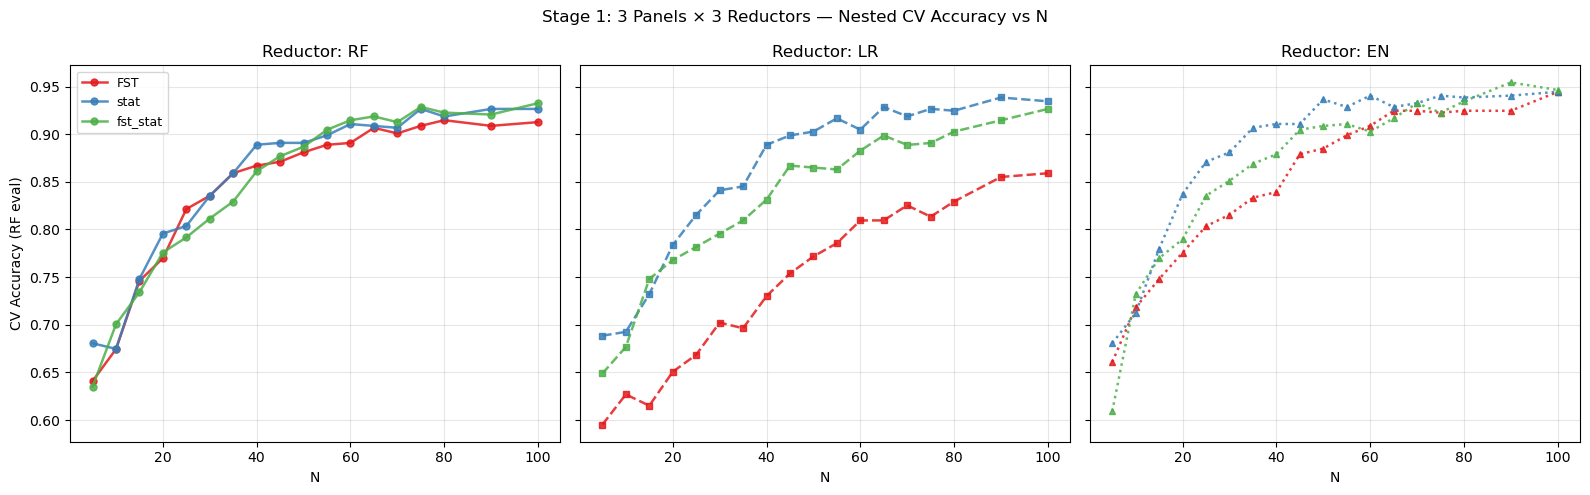

In [10]:
# Stage 1 visual: accuracy vs N for each (panel, reductor) combination
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
panel_colors = {'FST': '#e41a1c', 'stat': '#377eb8', 'fst_stat': '#4daf4a'}
red_styles   = {'RF': '-o', 'LR': '--s', 'EN': ':^'}

for ax, rname in zip(axes, REDUCTORS):
    sub = stage1_df[stage1_df['reductor'] == rname]
    for pname, color in panel_colors.items():
        ps = sub[sub['panel'] == pname].sort_values('n_snps')
        ax.plot(ps['n_snps'], ps['acc_mean'],
                red_styles[rname], color=color, label=pname,
                linewidth=1.8, markersize=5, alpha=0.85)
    ax.set_title(f'Reductor: {rname}')
    ax.set_xlabel('N')
    ax.grid(alpha=0.3)
    if ax == axes[0]:
        ax.set_ylabel('CV Accuracy (RF eval)')
        ax.legend(fontsize=9)

plt.suptitle('Stage 1: 3 Panels × 3 Reductors — Nested CV Accuracy vs N',
             fontsize=12)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'stage1_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

## Stage 2: M Classifiers on Best Config per N

For each N, take the winning `(panel, reductor)` from Stage 1.
Run 5-fold CV with M classifiers. Ranker is re-fit inside every fold.
Reports acc / F1 / MCC / ROC-AUC for each classifier.

In [11]:
S2_CACHE = str(OUTPUT_DIR / 'stage2_results.csv')

if os.path.exists(S2_CACHE):
    print(f'Loading Stage 2 from cache: {S2_CACHE}')
    stage2_df = pd.read_csv(S2_CACHE)
else:
    stage2_records = []

    for _, s1_row in stage1_best.iterrows():
        N     = int(s1_row['n_snps'])
        pname = s1_row['panel']
        rname = s1_row['reductor']
        X, y_p, snp_ids = PANELS[pname]

        print(f'\nN={N:3d}: {pname} + {rname}')

        for fold_i, (tr_idx, te_idx) in enumerate(skf.split(X, y_p)):
            X_tr, X_te = X[tr_idx], X[te_idx]
            y_tr, y_te = y_p[tr_idx], y_p[te_idx]

            # Ranker re-fit on this fold's training data only
            imp, scaler = fit_reductor(rname, X_tr, y_tr)
            top_idx = np.argsort(imp)[::-1][:N]

            X_tr_n    = X_tr[:, top_idx]
            X_te_n    = X_te[:, top_idx]
            # Scaled versions (scaler fit on X_tr inside fit_reductor)
            X_tr_n_sc = scaler.transform(X_tr)[:, top_idx]
            X_te_n_sc = scaler.transform(X_te)[:, top_idx]

            for clf_name, (clf_tmpl, needs_scale) in CLASSIFIERS.items():
                X_tr_clf = X_tr_n_sc if needs_scale else X_tr_n
                X_te_clf = X_te_n_sc if needs_scale else X_te_n

                try:
                    clf = clone(clf_tmpl)
                    clf.fit(X_tr_clf, y_tr)
                    y_pred = clf.predict(X_te_clf)

                    acc  = accuracy_score(y_te, y_pred)
                    f1   = f1_score(y_te, y_pred, average='weighted')
                    mcc  = matthews_corrcoef(y_te, y_pred)
                    rauc = None
                    if hasattr(clf, 'predict_proba'):
                        y_prob = clf.predict_proba(X_te_clf)
                        rauc = roc_auc_score(
                            y_te, y_prob,
                            multi_class='ovr', average='macro')

                    stage2_records.append({
                        'n_snps':     N,
                        'panel':      pname,
                        'reductor':   rname,
                        'classifier': clf_name,
                        'fold':       fold_i,
                        'acc':  acc, 'f1': f1,
                        'mcc':  mcc, 'roc_auc': rauc,
                    })
                except Exception as exc:
                    print(f'  ERROR {clf_name} fold {fold_i}: {exc}')

            print(f'  fold {fold_i+1}/{N_CV}', end='\r')
        print(f'  N={N} done        ')

    stage2_df = pd.DataFrame(stage2_records)
    stage2_df.to_csv(S2_CACHE, index=False)
    print(f'\nStage 2 saved: {S2_CACHE}  ({len(stage2_df)} rows)')

print(stage2_df.shape)


N=  5: stat + LR


  N=5 done        

N= 10: fst_stat + EN
  N=10 done        

N= 15: stat + EN
  N=15 done        

N= 20: stat + EN
  N=20 done        

N= 25: stat + EN
  N=25 done        

N= 30: stat + EN
  N=30 done        

N= 35: stat + EN
  N=35 done        

N= 40: stat + EN
  N=40 done        

N= 45: stat + EN
  N=45 done        

N= 50: stat + EN
  N=50 done        

N= 55: stat + EN
  N=55 done        

N= 60: stat + EN
  N=60 done        

N= 65: stat + LR
  N=65 done        

N= 70: stat + EN
  N=70 done        

N= 75: stat + EN
  N=75 done        

N= 80: stat + EN
  N=80 done        

N= 90: fst_stat + EN
  N=90 done        

N=100: fst_stat + EN
  N=100 done        

Stage 2 saved: /mnt/data/aisnp_data/1000genomes/outputs/self_evaluation/08_unified_panel_sweep/stage2_results.csv  (540 rows)
(540, 9)


In [12]:
# Aggregate across folds
stage2_agg = (
    stage2_df.groupby(['n_snps','panel','reductor','classifier'])
    .agg(
        acc_mean=('acc','mean'), acc_std=('acc','std'),
        f1_mean=('f1','mean'),   mcc_mean=('mcc','mean'),
        roc_auc_mean=('roc_auc','mean')
    )
    .reset_index()
)
stage2_agg.to_csv(str(OUTPUT_DIR / 'stage2_agg.csv'), index=False)

# Best classifier per N
stage2_best = (
    stage2_agg.sort_values('acc_mean', ascending=False)
    .groupby('n_snps').first()
    .reset_index()
    [['n_snps','panel','reductor','classifier',
      'acc_mean','acc_std','f1_mean','mcc_mean','roc_auc_mean']]
    .sort_values('n_snps')
)
stage2_best.to_csv(str(OUTPUT_DIR / 'stage2_best.csv'), index=False)

print('Stage 2 — best classifier per N:')
print('=' * 100)
print(stage2_best.to_string(index=False))

Stage 2 — best classifier per N:
 n_snps    panel reductor classifier  acc_mean  acc_std  f1_mean  mcc_mean  roc_auc_mean
      5     stat       LR         LR  0.692455 0.053336 0.668595  0.519185      0.821445
     10 fst_stat       EN    SVM_Lin  0.759861 0.057385 0.755758  0.624841      0.898669
     15     stat       EN    SVM_RBF  0.805485 0.026570 0.799445  0.696849      0.917733
     20     stat       EN         LR  0.845208 0.053708 0.842829  0.758354      0.953067
     25     stat       EN         RF  0.865030 0.027110 0.861481  0.790316      0.964635
     30     stat       EN         LR  0.892950 0.030608 0.891946  0.833997      0.966121
     35     stat       EN         LR  0.922594 0.013119 0.922226  0.879830      0.980116
     40     stat       EN         LR  0.916614 0.028773 0.916251  0.870671      0.980850
     45     stat       EN         LR  0.928475 0.029688 0.927964  0.889736      0.985636
     50     stat       EN    SVM_RBF  0.930535 0.014146 0.929710  0.892498   

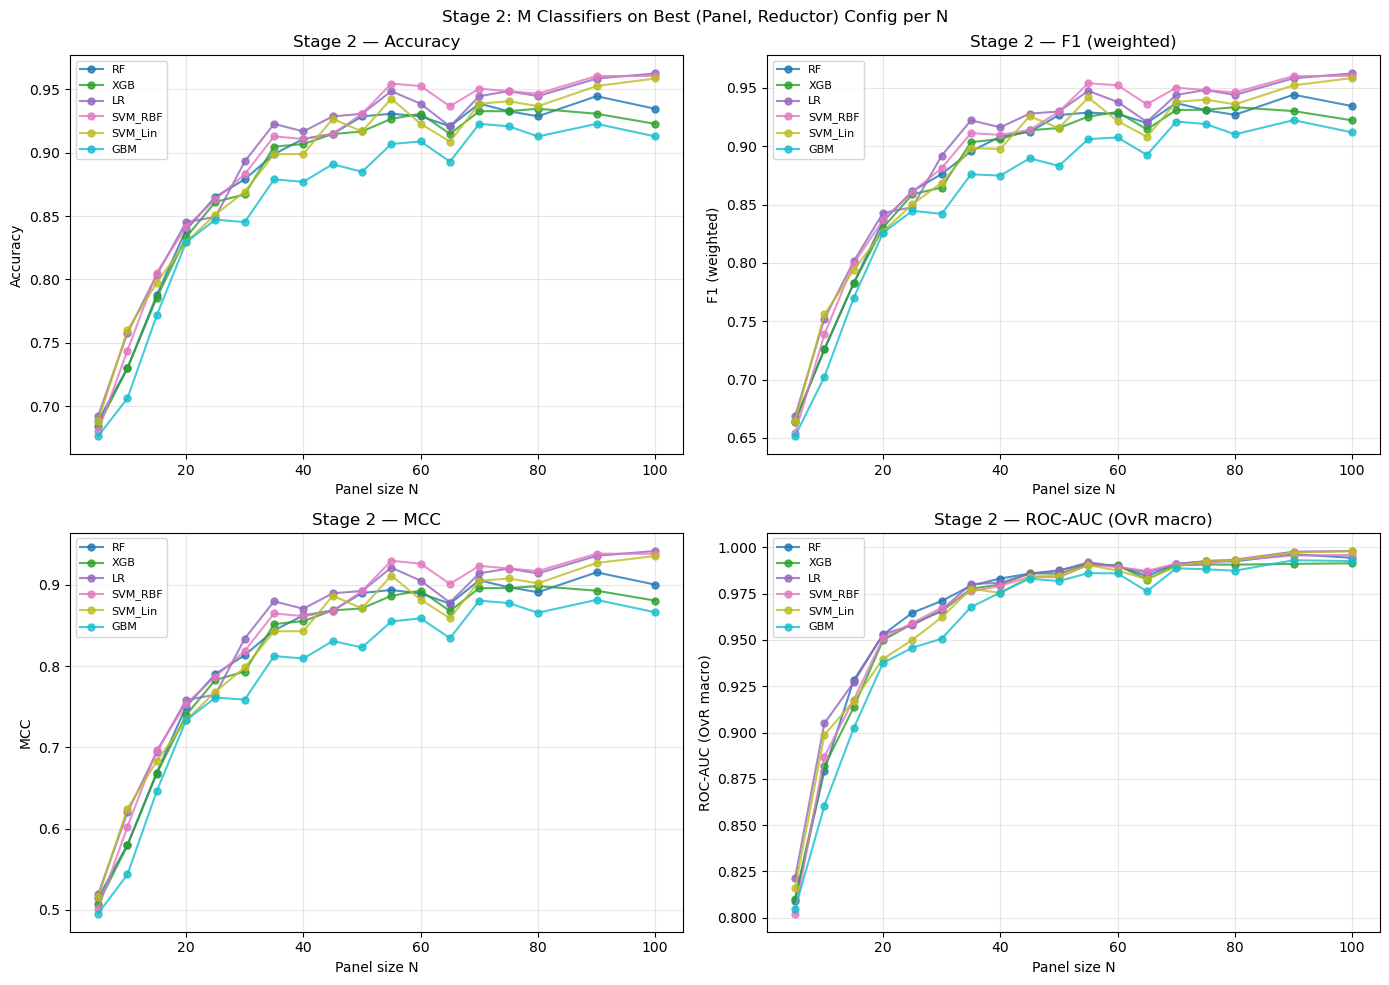

In [13]:
# Stage 2 performance curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
clf_colors = dict(zip(
    CLASSIFIERS.keys(),
    plt.cm.tab10(np.linspace(0, 1, len(CLASSIFIERS)))
))
metrics = [
    ('acc_mean',     'Accuracy'),
    ('f1_mean',      'F1 (weighted)'),
    ('mcc_mean',     'MCC'),
    ('roc_auc_mean', 'ROC-AUC (OvR macro)'),
]

for ax_idx, (metric, label) in enumerate(metrics):
    ax = axes[ax_idx // 2, ax_idx % 2]
    for clf_name, color in clf_colors.items():
        sub = stage2_agg[stage2_agg['classifier'] == clf_name].sort_values('n_snps')
        if sub.empty or sub[metric].isna().all():
            continue
        ax.plot(sub['n_snps'], sub[metric], 'o-',
                color=color, label=clf_name,
                linewidth=1.5, markersize=5, alpha=0.8)
    ax.set_xlabel('Panel size N')
    ax.set_ylabel(label)
    ax.set_title(f'Stage 2 — {label}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Stage 2: M Classifiers on Best (Panel, Reductor) Config per N',
             fontsize=12)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'stage2_performance.png'), dpi=150, bbox_inches='tight')
plt.show()

## Stage 3: Final Panel Commitment

For each N:
1. Take the winning `(panel, reductor)` from Stage 1 and best classifier from Stage 2.
2. 80/20 stratified split.
3. Fit reductor on 80% → select top N SNPs → **this is the final panel**.
4. Train best classifier on 80%, evaluate on 20%.

The 80% reductor fit gives the concrete SNP list; the 20% test is a confirmation score.
Reliable performance estimates are from Stage 2 CV (5-fold).

In [14]:
S3_CACHE = str(OUTPUT_DIR / 'stage3_results.csv')

if os.path.exists(S3_CACHE):
    print(f'Loading Stage 3 from cache: {S3_CACHE}')
    stage3_df = pd.read_csv(S3_CACHE)
else:
    stage3_records = []

    for _, s1_row in stage1_best.iterrows():
        N     = int(s1_row['n_snps'])
        pname = s1_row['panel']
        rname = s1_row['reductor']

        s2_row   = stage2_best[stage2_best['n_snps'] == N].iloc[0]
        clf_name = s2_row['classifier']

        X, y_p, snp_ids = PANELS[pname]
        clf_tmpl, needs_scale = CLASSIFIERS[clf_name]

        # Single 80/20 stratified split
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y_p, test_size=0.2, stratify=y_p,
            random_state=RANDOM_STATE)

        # Fit reductor on 80% training data
        imp, scaler = fit_reductor(rname, X_tr, y_tr)
        top_idx    = np.argsort(imp)[::-1][:N]
        final_snps = [snp_ids[i] for i in top_idx]

        X_tr_n    = X_tr[:, top_idx]
        X_te_n    = X_te[:, top_idx]
        X_tr_n_sc = scaler.transform(X_tr)[:, top_idx]
        X_te_n_sc = scaler.transform(X_te)[:, top_idx]

        X_tr_clf = X_tr_n_sc if needs_scale else X_tr_n
        X_te_clf = X_te_n_sc if needs_scale else X_te_n

        clf = clone(clf_tmpl)
        clf.fit(X_tr_clf, y_tr)
        y_pred = clf.predict(X_te_clf)

        acc  = float(accuracy_score(y_te, y_pred))
        f1   = float(f1_score(y_te, y_pred, average='weighted'))
        mcc  = float(matthews_corrcoef(y_te, y_pred))
        rauc = None
        if hasattr(clf, 'predict_proba'):
            y_prob = clf.predict_proba(X_te_clf)
            rauc = float(roc_auc_score(
                y_te, y_prob, multi_class='ovr', average='macro'))

        stage3_records.append({
            'n_snps':     N,
            'panel':      pname,
            'reductor':   rname,
            'classifier': clf_name,
            'n_train':    len(X_tr),
            'n_test':     len(X_te),
            'acc':  acc,  'f1':  f1,
            'mcc':  mcc,  'roc_auc': rauc,
        })

        # Save this N's final panel
        panel_df = pd.DataFrame({
            'rank':             range(1, N+1),
            'snp_id':           final_snps,
            'reductor_score':   np.sort(imp)[::-1][:N],
        })
        panel_df.to_csv(str(PANELS_DIR / f'panel_N{N:03d}.csv'), index=False)

        rauc_str = f'{rauc:.4f}' if rauc is not None else 'N/A'
        print(f'N={N:3d}: {pname}+{rname}+{clf_name}  '
              f'acc={acc:.4f}  f1={f1:.4f}  '
              f'mcc={mcc:.4f}  roc_auc={rauc_str}')

    stage3_df = pd.DataFrame(stage3_records)
    stage3_df.to_csv(S3_CACHE, index=False)
    print(f'\nStage 3 saved: {S3_CACHE}')
    print(f'Final panels:  {PANELS_DIR}')

print(stage3_df.shape)

N=  5: stat+LR+LR  acc=0.6040  f1=0.5463  mcc=0.3651  roc_auc=0.7747
N= 10: fst_stat+EN+SVM_Lin  acc=0.7426  f1=0.7406  mcc=0.6160  roc_auc=0.8832
N= 15: stat+EN+SVM_RBF  acc=0.7624  f1=0.7559  mcc=0.6264  roc_auc=0.9005
N= 20: stat+EN+LR  acc=0.8020  f1=0.7991  mcc=0.6918  roc_auc=0.9297
N= 25: stat+EN+RF  acc=0.8020  f1=0.7959  mcc=0.6913  roc_auc=0.9190
N= 30: stat+EN+LR  acc=0.8515  f1=0.8486  mcc=0.7687  roc_auc=0.9258
N= 35: stat+EN+LR  acc=0.8812  f1=0.8800  mcc=0.8176  roc_auc=0.9633
N= 40: stat+EN+LR  acc=0.8812  f1=0.8809  mcc=0.8144  roc_auc=0.9749
N= 45: stat+EN+LR  acc=0.9109  f1=0.9107  mcc=0.8620  roc_auc=0.9789
N= 50: stat+EN+SVM_RBF  acc=0.9010  f1=0.9002  mcc=0.8474  roc_auc=0.9815
N= 55: stat+EN+SVM_RBF  acc=0.9208  f1=0.9206  mcc=0.8783  roc_auc=0.9783
N= 60: stat+EN+SVM_RBF  acc=0.9109  f1=0.9099  mcc=0.8614  roc_auc=0.9765
N= 65: stat+LR+SVM_RBF  acc=0.8614  f1=0.8572  mcc=0.7839  roc_auc=0.9600
N= 70: stat+EN+SVM_RBF  acc=0.9010  f1=0.8997  mcc=0.8491  roc_auc=0.

## Summary

In [15]:
print('=' * 80)
print('UNIFIED PANEL SWEEP — SUMMARY')
print('=' * 80)
print(f'Panels:      {list(PANELS)}')
print(f'Reductors:   {REDUCTORS}')
print(f'Classifiers: {list(CLASSIFIERS)}')
print(f'Panel sizes: N in {PANEL_SIZES}')
print()
print(f'{"N":>4}  {"S1 Panel":>11}  {"S1 Red":>5}  {"S1 Acc":>7}  '
      f'{"S2 Clf":>8}  {"S2 Acc":>7}  {"S2 MCC":>7}  {"S3 Acc":>7}')
print('-' * 75)
for N in PANEL_SIZES:
    s1 = stage1_best[stage1_best['n_snps'] == N].iloc[0]
    s2 = stage2_best[stage2_best['n_snps'] == N].iloc[0]
    s3 = stage3_df[stage3_df['n_snps']    == N].iloc[0]
    print(f"{N:4d}  {s1['panel']:>11}  {s1['reductor']:>5}  "
          f"{s1['acc_mean']:>7.4f}  {s2['classifier']:>8}  "
          f"{s2['acc_mean']:>7.4f}  {s2['mcc_mean']:>7.4f}  "
          f"{s3['acc']:>7.4f}")

print()
print(f'Output directory: {OUTPUT_DIR}')
print(f'Final panels:     {PANELS_DIR}')
print()
print('Reported performance: Stage 2 CV (5-fold, leak-free).')
print('Stage 3 acc is a single-split confirmation, not the primary metric.')

UNIFIED PANEL SWEEP — SUMMARY
Panels:      ['FST', 'stat', 'fst_stat']
Reductors:   ['RF', 'LR', 'EN']
Classifiers: ['RF', 'XGB', 'LR', 'SVM_RBF', 'SVM_Lin', 'GBM']
Panel sizes: N in [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 90, 100]

   N     S1 Panel  S1 Red   S1 Acc    S2 Clf   S2 Acc   S2 MCC   S3 Acc
---------------------------------------------------------------------------
   5         stat     LR   0.6885        LR   0.6925   0.5192   0.6040
  10     fst_stat     EN   0.7322   SVM_Lin   0.7599   0.6248   0.7426
  15         stat     EN   0.7797   SVM_RBF   0.8055   0.6968   0.7624
  20         stat     EN   0.8372        LR   0.8452   0.7584   0.8020
  25         stat     EN   0.8710        RF   0.8650   0.7903   0.8020
  30         stat     EN   0.8810        LR   0.8930   0.8340   0.8515
  35         stat     EN   0.9068        LR   0.9226   0.8798   0.8812
  40         stat     EN   0.9107        LR   0.9166   0.8707   0.8812
  45         stat     EN   